In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [6]:
# Define paths (CHANGE THIS to your actual path)
train_path = "/content/drive/MyDrive/train"
test_path = "/content/drive/MyDrive/test"
# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))
print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")
# YOUR CODE HERE: Print the number of test images
# Hint: Look at the code above and modify it for test_path
#
#


Hot dog images: 249
Not hot dog images: 249


In [7]:
# Count test images
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test Hot dog images: {test_hot_dog_count}")
print(f"Test Not hot dog images: {test_not_hot_dog_count}")

Test Hot dog images: 250
Test Not hot dog images: 250


Image shape (height, width, channels): (512, 382, 3)


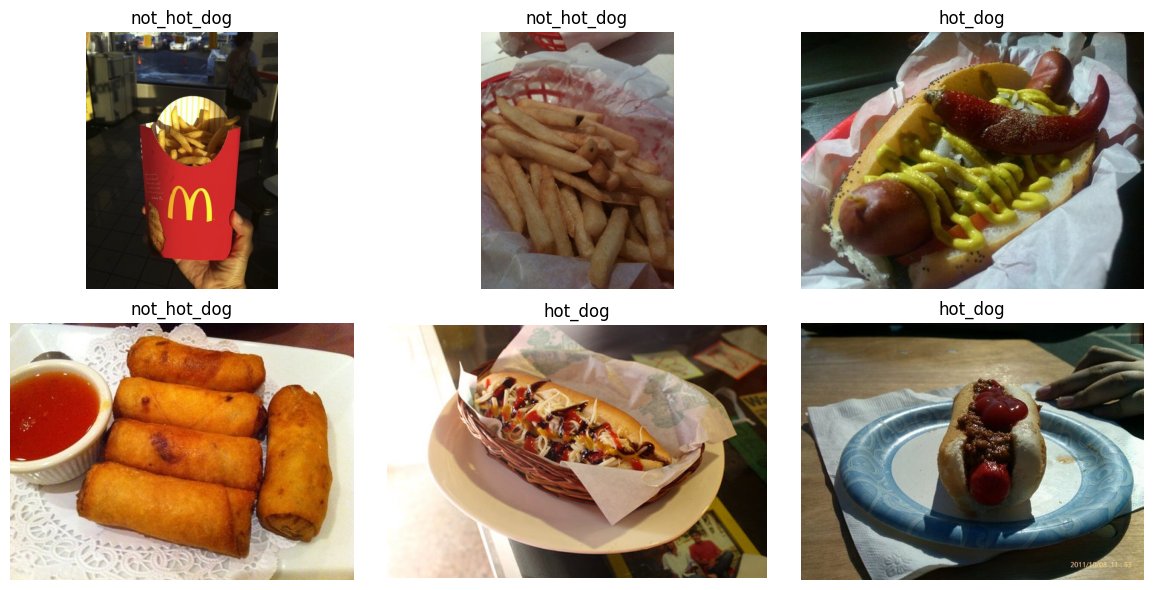

In [8]:
plt.figure(figsize=(12, 6))

for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)

    # Print shape of the first image only
    if i == 0:
        print("Image shape (height, width, channels):", img.shape)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is more accurate)
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values from 0-255 to 0-1
    validation_split=0.2     # Use 20% of training data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',     # Binary classification (hot dog vs not)
    subset='training'        # Training set (80% of data)
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'      # Validation set (20% of data)
)

# Print the class labels
print("Class labels:", train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class labels: {'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.4625 - loss: 1.7940 - val_accuracy: 0.5000 - val_loss: 1.3499
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.5175 - loss: 1.1943 - val_accuracy: 0.5510 - val_loss: 0.7838
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.6425 - loss: 0.6751 - val_accuracy: 0.5306 - val_loss: 0.7324
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 295ms/step - accuracy: 0.7100 - loss: 0.5633 - val_accuracy: 0.5306 - val_loss: 0.7791
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - accuracy: 0.7075 - loss: 0.5587 - val_accuracy: 0.5102 - val_loss: 0.7900
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.7250 - loss: 0.5610 - val_accuracy: 0.5204 - val_loss: 0.7571
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.7725 - loss: 0.4875 - val_accuracy: 0.5510 - val_loss: 0.8132
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.7200 - loss: 0.5303 - val_accuracy: 0.

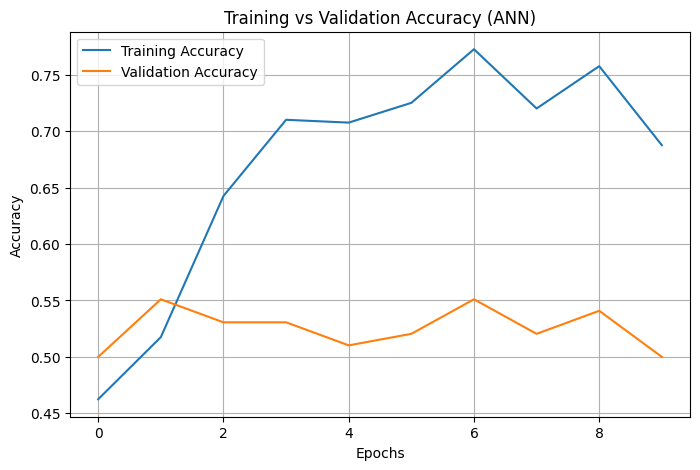

In [10]:
# Build a simple ANN
ann_model = keras.Sequential([
    # Flatten the 2D image into 1D
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
ann_model.summary()

# Train for 10 epochs
history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot training vs validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy (ANN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

In [11]:
# Build CNN model
cnn_model = keras.Sequential([
    # First Conv layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Conv layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Conv layer (added)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
cnn_model.summary()

# Train the CNN
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 464ms/step - accuracy: 0.4900 - loss: 0.7020 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 482ms/step - accuracy: 0.5750 - loss: 0.6863 - val_accuracy: 0.6020 - val_loss: 0.6779
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.6100 - loss: 0.6615 - val_accuracy: 0.4898 - val_loss: 0.7510
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.5950 - loss: 0.6633 - val_accuracy: 0.5918 - val_loss: 0.6612
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - accuracy: 0.6100 - loss: 0.6433 - val_accuracy: 0.6327 - val_loss: 0.6665
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 353ms/step - accuracy: 0.6700 - loss: 0.6093 - val_accuracy: 0.5918 - val_loss: 0.6511
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.7050 - loss: 0.5672 - val_accuracy: 0.6429 - val_loss: 0.7126
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 375ms/step - accuracy: 0.7225 - loss: 0.5445 - val_accuracy: 0

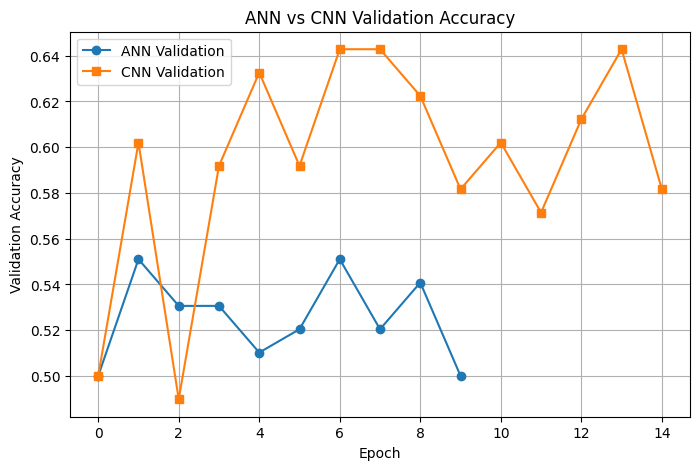

In [12]:


plt.figure(figsize=(8, 5))

plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)

plt.show()

In [13]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Improved model with Dropout to reduce overfitting
improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),   # Dropout 1

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),   # Dropout 2

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),    # Dropout 3

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),    # Dropout before output

    layers.Dense(1, activation='sigmoid')
])

# Compile the model
improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the improved model
history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 444ms/step - accuracy: 0.4775 - loss: 0.7201 - val_accuracy: 0.5102 - val_loss: 0.6924
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 526ms/step - accuracy: 0.4750 - loss: 0.6982 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.5125 - loss: 0.6895 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.5175 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 541ms/step - accuracy: 0.4900 - loss: 0.6937 - val_accuracy: 0.5918 - val_loss: 0.6919
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - accuracy: 0.5025 - loss: 0.6942 - val_accuracy: 0.5612 - val_loss: 0.6914
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.5725 - loss: 0.6884 - val_accuracy: 0.5306 - val_loss: 0.6890
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 507ms/step - accuracy: 0.5500 - loss: 0.6819 - val_accuracy: 0.

In [30]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers

# Data Augmentation
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Training generator with augmentation
train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Validation generator (same split, no augmentation applied automatically)
validation_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Final model (same as improved_model)
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# Compile
final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with augmented data
history_final = final_model.fit(
    train_augmented,
    validation_data=validation_augmented,
    epochs=15
)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 712ms/step - accuracy: 0.4775 - loss: 0.7035 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 475ms/step - accuracy: 0.4900 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 675ms/step - accuracy: 0.4875 - loss: 0.7049 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 473ms/step - accuracy: 0.5100 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 625ms/step - accuracy: 0.5150 - loss: 0.6906 - val_accuracy: 0.5816 - val_loss: 0.6918
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step - accuracy: 0.5225 - loss: 0.6924 - val_accuracy: 0.5816 - val_loss: 0.6896
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 606ms/step - accuracy: 0.5650 - loss: 0.6848 - val_accuracy: 0.6122 - val_loss: 0.6836
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.5975 - loss: 0.6758 - val_accuracy: 0

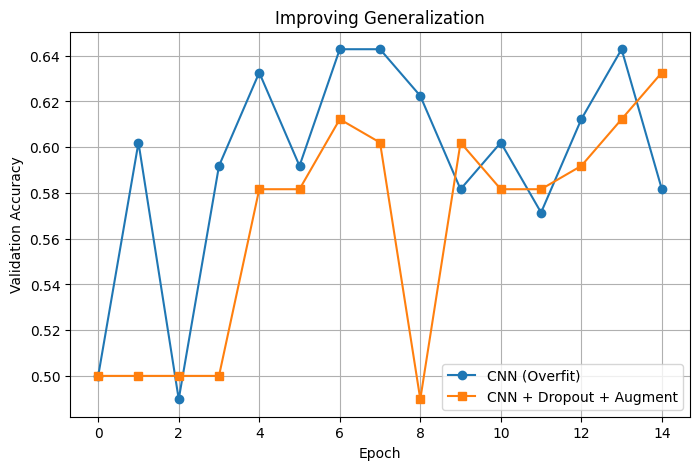

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
❌ NOT A HOT DOG! (confidence: 0.55)


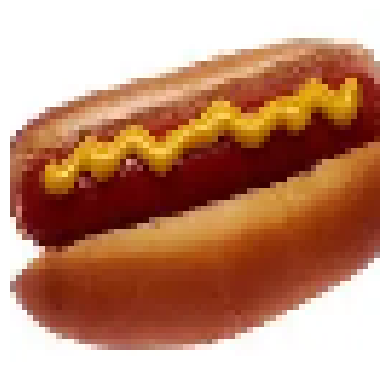

In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))

    # Preprocess
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]

    if prediction > 0.5:
        print(f"🌭 HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"❌ NOT A HOT DOG! (confidence: {1 - prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# ✅ Call function HERE (not inside def)
predict_image("/content/drive/MyDrive/download.webp")


image 1/1 /content/drive/MyDrive/download.webp: 384x640 1 hot dog, 165.0ms
Speed: 2.8ms preprocess, 165.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


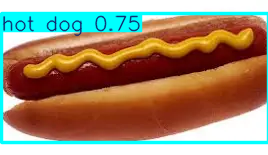

hot dog (0.75)


In [35]:
# Install Ultralytics YOLO
!pip install ultralytics

from ultralytics import YOLO

# Load a tiny pre-trained model (fast)
yolo_model = YOLO("yolov8n.pt")  # n = nano

# Path to your image (CHANGE THIS to your actual file)
image_path = "/content/drive/MyDrive/download.webp"

# Run detection
results = yolo_model(image_path)

# Show results (draws bounding boxes)
results[0].show()

# OPTIONAL: Print detected object labels
for box in results[0].boxes:
    class_id = int(box.cls[0])
    label = yolo_model.names[class_id]
    confidence = float(box.conf[0])
    print(f"{label} ({confidence:.2f})")